In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from datetime import datetime
from datetime import timedelta

# 11.1 types and tools of date and time data

In [4]:
now = datetime.now()

In [5]:
now

datetime.datetime(2025, 11, 28, 23, 22, 58, 415340)

In [6]:
now.year, now.month, now.day

(2025, 11, 28)

In [7]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8,15)

In [8]:
delta

datetime.timedelta(days=926, seconds=56700)

In [9]:
delta.days

926

In [10]:
delta.seconds

56700

In [11]:
start = datetime(2011, 1, 7)

In [12]:
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

In [13]:
start - 2 * timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

In [14]:
stamp = datetime(2011, 1, 3)

In [15]:
str(stamp)

'2011-01-03 00:00:00'

In [16]:
stamp.strftime("%Y-%M-%d")

'2011-00-03'

In [17]:
value = "2011-01-03"

In [18]:
datetime.strptime(value, "%Y-%m-%d")

datetime.datetime(2011, 1, 3, 0, 0)

In [19]:
datestrs = ["7/6/2011", "8/6/2011"]

In [20]:
[datetime.strptime(x, "%m/%d/%Y") for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

In [21]:
datestrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00"]

In [22]:
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

In [23]:
idx = pd.to_datetime(datestrs + [None])

In [24]:
idx

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [25]:
idx[2]

NaT

In [26]:
pd.isna(idx)

array([False, False,  True])

# 11.2 basic knowledge of time series

In [27]:
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]

In [28]:
ts = pd.Series(np.random.standard_normal(6), index=dates)

In [29]:
ts

2011-01-02    0.151811
2011-01-05    0.503447
2011-01-07    0.916670
2011-01-08   -1.335790
2011-01-10    0.895774
2011-01-12   -0.335762
dtype: float64

In [30]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

In [31]:
ts +ts[::2]

2011-01-02    0.303623
2011-01-05         NaN
2011-01-07    1.833340
2011-01-08         NaN
2011-01-10    1.791547
2011-01-12         NaN
dtype: float64

In [32]:
ts.index.dtype

dtype('<M8[ns]')

In [33]:
stamp = ts.index[0]

In [34]:
stamp

Timestamp('2011-01-02 00:00:00')

# 11.2.1 index select subset construction

In [35]:
stamp = ts.index[2]

In [36]:
ts[stamp]

np.float64(0.9166698429891423)

In [37]:
ts["2011-01-10"]

np.float64(0.8957736635644171)

In [38]:
longer_ts = pd.Series(np.random.standard_normal(1000),
                      index=pd.date_range("2000-01-01", periods=1000))

In [39]:
longer_ts

2000-01-01   -0.244578
2000-01-02    0.414289
2000-01-03   -0.401279
2000-01-04   -0.488905
2000-01-05   -0.792020
                ...   
2002-09-22    1.870316
2002-09-23    0.668971
2002-09-24   -1.176726
2002-09-25   -1.216560
2002-09-26    1.905990
Freq: D, Length: 1000, dtype: float64

In [40]:
longer_ts["2001"]

2001-01-01   -1.378120
2001-01-02   -0.986249
2001-01-03    0.629065
2001-01-04   -0.631521
2001-01-05   -1.282853
                ...   
2001-12-27    0.392784
2001-12-28    0.612952
2001-12-29   -0.514110
2001-12-30    0.348589
2001-12-31   -1.148746
Freq: D, Length: 365, dtype: float64

In [41]:
longer_ts["2001-05"]

2001-05-01   -0.351057
2001-05-02   -1.297713
2001-05-03   -0.260440
2001-05-04    0.814799
2001-05-05    0.501163
2001-05-06    1.431858
2001-05-07    1.438565
2001-05-08   -0.628257
2001-05-09    1.766240
2001-05-10   -0.222752
2001-05-11    0.303568
2001-05-12   -0.428976
2001-05-13    0.015546
2001-05-14    0.497008
2001-05-15   -0.502473
2001-05-16   -0.397108
2001-05-17   -0.242588
2001-05-18   -1.280245
2001-05-19    0.546634
2001-05-20    0.474404
2001-05-21    0.124729
2001-05-22    0.111362
2001-05-23    0.264099
2001-05-24    2.019686
2001-05-25    0.393257
2001-05-26   -0.933580
2001-05-27   -0.502086
2001-05-28   -1.199251
2001-05-29    0.831929
2001-05-30    0.808739
2001-05-31    0.377790
Freq: D, dtype: float64

In [42]:
ts[datetime(2011, 1, 7):]

2011-01-07    0.916670
2011-01-08   -1.335790
2011-01-10    0.895774
2011-01-12   -0.335762
dtype: float64

In [43]:
ts[datetime(2011, 1, 7):datetime(2011, 1, 10)]

2011-01-07    0.916670
2011-01-08   -1.335790
2011-01-10    0.895774
dtype: float64

In [44]:
ts

2011-01-02    0.151811
2011-01-05    0.503447
2011-01-07    0.916670
2011-01-08   -1.335790
2011-01-10    0.895774
2011-01-12   -0.335762
dtype: float64

In [45]:
ts["2011-01-06":"2011-01-11"]

2011-01-07    0.916670
2011-01-08   -1.335790
2011-01-10    0.895774
dtype: float64

In [46]:
ts.truncate(after="2011-01-09")

2011-01-02    0.151811
2011-01-05    0.503447
2011-01-07    0.916670
2011-01-08   -1.335790
dtype: float64

In [47]:
dates = pd.date_range("2000-01-01", periods=100, freq="W-WED")

In [48]:
long_df = pd.DataFrame(np.random.standard_normal((100,4)),
                       index=dates,
                       columns=["Colorado", "Texas",
                                "New York", "Ohio"])

In [49]:
long_df.loc["2001-05"]

,Colorado,Texas,New York,Ohio
2001-05-02,-2.000777,-0.449477,-0.546494,0.129925
2001-05-09,0.548363,-0.393850,-0.946042,1.425483
2001-05-16,-0.649898,-0.256209,0.012216,-1.062627
2001-05-23,-0.352469,1.172652,-0.731950,0.346144
2001-05-30,-0.435457,-1.878381,-0.596695,-0.857342


# 11.2.2 time series with duplicate indexes

In [50]:
dates = pd.DatetimeIndex(["2000-01-01", "2000-01-02", "2000-01-02",
                      "2000-01-02", "2000-01-03"])

In [51]:
dup_ts = pd.Series(np.arange(5), index=dates)

In [52]:
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

In [53]:
dup_ts.index.is_unique

False

In [54]:
dup_ts["2000-01-03"]

np.int64(4)

In [55]:
dup_ts["2000-01-02"]

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

In [56]:
grouped = dup_ts.groupby(level=0)

In [57]:
grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [58]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

# 11.3 Range,frequency,and shift of dates

In [59]:
ts

2011-01-02    0.151811
2011-01-05    0.503447
2011-01-07    0.916670
2011-01-08   -1.335790
2011-01-10    0.895774
2011-01-12   -0.335762
dtype: float64

In [60]:
resampler = ts.resample("D")

In [61]:
resampler

# 11.3.1 Generate date range

In [62]:
index = pd.date_range("2012-04-01", "2012-06-01")

In [63]:
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

In [64]:
pd.date_range(start="2012-04-01", periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [65]:
pd.date_range(end="2012-06-01", periods=20)

DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

In [66]:
pd.date_range("2000-01-01", "2000-12-01", freq="BM")

/tmp/ipykernel_5075/3742551278.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  pd.date_range("2000-01-01", "2000-12-01", freq="BM")


DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [67]:
pd.date_range("2012-05-02 12:56:31", periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

In [68]:
pd.date_range("2012-05-02 12:56:31", periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

# 11.3.2 Frequency and date offset

In [69]:
from pandas.tseries.offsets import Hour, Minute

In [70]:
hour = Hour()

In [71]:
hour

<Hour>

In [72]:
four_hours = Hour(4)

In [73]:
four_hours

<4 * Hours>

In [74]:
pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4H")

/tmp/ipykernel_5075/3449897904.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4H")


DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

In [75]:
Hour(2) + Minute(30)

<150 * Minutes>

In [76]:
pd.date_range("2000-01-01", periods=10, freq="1h30min")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

In [77]:
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq="WOM-3FRI")

In [78]:
list(monthly_dates)

[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

# 11.3.3 Shift the leading and lagging data

In [79]:
ts = pd.Series(np.random.standard_normal(4),
               index=pd.date_range("2000-01-01", periods=4, freq="M"))

/tmp/ipykernel_5075/2098005487.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.date_range("2000-01-01", periods=4, freq="M"))


In [80]:
ts

2000-01-31   -0.247253
2000-02-29   -1.363274
2000-03-31   -1.047277
2000-04-30   -0.388030
Freq: ME, dtype: float64

In [81]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31   -0.247253
2000-04-30   -1.363274
Freq: ME, dtype: float64

In [82]:
ts.shift(-2)

2000-01-31   -1.047277
2000-02-29   -0.388030
2000-03-31         NaN
2000-04-30         NaN
Freq: ME, dtype: float64

In [83]:
ts.shift(2, freq="M")

/tmp/ipykernel_5075/903147437.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.shift(2, freq="M")


2000-03-31   -0.247253
2000-04-30   -1.363274
2000-05-31   -1.047277
2000-06-30   -0.388030
Freq: ME, dtype: float64

In [84]:
ts.shift(2, freq="ME")

2000-03-31   -0.247253
2000-04-30   -1.363274
2000-05-31   -1.047277
2000-06-30   -0.388030
Freq: ME, dtype: float64

In [85]:
ts.shift(3, freq="D")

2000-02-03   -0.247253
2000-03-03   -1.363274
2000-04-03   -1.047277
2000-05-03   -0.388030
dtype: float64

In [86]:
ts.shift(1, freq="90T")

/tmp/ipykernel_5075/584021106.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts.shift(1, freq="90T")


2000-01-31 01:30:00   -0.247253
2000-02-29 01:30:00   -1.363274
2000-03-31 01:30:00   -1.047277
2000-04-30 01:30:00   -0.388030
dtype: float64

In [87]:
ts.shift(1, freq="90min")

2000-01-31 01:30:00   -0.247253
2000-02-29 01:30:00   -1.363274
2000-03-31 01:30:00   -1.047277
2000-04-30 01:30:00   -0.388030
dtype: float64

In [88]:
from pandas.tseries.offsets import Day, MonthEnd

In [89]:
now = datetime(2011, 11, 17)

In [90]:
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

In [91]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

In [92]:
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [93]:
offset = MonthEnd()

In [94]:
offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [95]:
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

In [96]:
ts = pd.Series(np.random.standard_normal(20),
               index=pd.date_range("2000-01-15", periods=20, freq="4D"))

In [97]:
ts

2000-01-15    0.482277
2000-01-19   -1.662526
2000-01-23   -0.501757
2000-01-27    1.744709
2000-01-31   -0.273028
2000-02-04    0.504893
2000-02-08    0.520095
2000-02-12    0.514749
2000-02-16    0.032258
2000-02-20    1.464700
2000-02-24   -1.157798
2000-02-28    0.358556
2000-03-03    0.128460
2000-03-07    0.266145
2000-03-11    1.262980
2000-03-15    0.348345
2000-03-19    0.598683
2000-03-23    0.799995
2000-03-27   -0.281146
2000-03-31   -1.426107
Freq: 4D, dtype: float64

In [98]:
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.042065
2000-02-29    0.319636
2000-03-31    0.212169
dtype: float64

In [99]:
ts.resample("ME").mean()

2000-01-31   -0.042065
2000-02-29    0.319636
2000-03-31    0.212169
Freq: ME, dtype: float64

# 11.4 Time zone process

In [100]:
import pytz

In [101]:
pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [102]:
tz = pytz.timezone("America/New_York")

In [103]:
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

# 11.4.1 Localization and Conversion of Time zones

In [104]:
dates = pd.date_range("2012-03-09 09:30", periods=6)

In [105]:
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)

In [106]:
ts

2012-03-09 09:30:00    0.934822
2012-03-10 09:30:00   -0.095440
2012-03-11 09:30:00    0.709973
2012-03-12 09:30:00    0.830810
2012-03-13 09:30:00    0.746709
2012-03-14 09:30:00   -1.104669
Freq: D, dtype: float64

In [107]:
print(ts.index.tz)

None


In [108]:
pd.date_range("2012-03-09 09:30", periods=10, tz="UTC")

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [109]:
ts

2012-03-09 09:30:00    0.934822
2012-03-10 09:30:00   -0.095440
2012-03-11 09:30:00    0.709973
2012-03-12 09:30:00    0.830810
2012-03-13 09:30:00    0.746709
2012-03-14 09:30:00   -1.104669
Freq: D, dtype: float64

In [110]:
ts_utc = ts.tz_localize("UTC")

In [111]:
ts_utc

2012-03-09 09:30:00+00:00    0.934822
2012-03-10 09:30:00+00:00   -0.095440
2012-03-11 09:30:00+00:00    0.709973
2012-03-12 09:30:00+00:00    0.830810
2012-03-13 09:30:00+00:00    0.746709
2012-03-14 09:30:00+00:00   -1.104669
Freq: D, dtype: float64

In [112]:
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [113]:
ts_utc.tz_convert("America/New_York")

2012-03-09 04:30:00-05:00    0.934822
2012-03-10 04:30:00-05:00   -0.095440
2012-03-11 05:30:00-04:00    0.709973
2012-03-12 05:30:00-04:00    0.830810
2012-03-13 05:30:00-04:00    0.746709
2012-03-14 05:30:00-04:00   -1.104669
Freq: D, dtype: float64

In [114]:
ts_eastern = ts.tz_localize("America/New_York")

In [115]:
ts_eastern.tz_convert("UTC")

2012-03-09 14:30:00+00:00    0.934822
2012-03-10 14:30:00+00:00   -0.095440
2012-03-11 13:30:00+00:00    0.709973
2012-03-12 13:30:00+00:00    0.830810
2012-03-13 13:30:00+00:00    0.746709
2012-03-14 13:30:00+00:00   -1.104669
dtype: float64

In [116]:
ts_eastern.tz_convert("Europe/Berlin")

2012-03-09 15:30:00+01:00    0.934822
2012-03-10 15:30:00+01:00   -0.095440
2012-03-11 14:30:00+01:00    0.709973
2012-03-12 14:30:00+01:00    0.830810
2012-03-13 14:30:00+01:00    0.746709
2012-03-14 14:30:00+01:00   -1.104669
dtype: float64

In [117]:
ts.index.tz_localize("Asia/Shanghai")

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

# 11.4.2 Operation on time zone type timestamp objects

In [118]:
stamp = pd.Timestamp("2011-03-12 04:00")

In [119]:
stamp_utc = stamp.tz_localize("utc")

In [120]:
stamp_utc.tz_convert("America/New_York")

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

In [121]:
stamp_moscow = pd.Timestamp("2011-03-12 04:00", tz="Europe/Moscow")

In [122]:
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

In [123]:
stamp_utc.value

1299902400000000000

In [124]:
stamp_utc.tz_convert("America/New_York").value

1299902400000000000

In [125]:
stamp = pd.Timestamp("2012-03-11 01:30", tz="US/Eastern")

In [126]:
stamp

Timestamp('2012-03-11 01:30:00-0500', tz='US/Eastern')

In [127]:
stamp + Hour()

Timestamp('2012-03-11 03:30:00-0400', tz='US/Eastern')

In [128]:
stamp = pd.Timestamp("2012-11-04 00:30", tz="US/Eastern")

In [129]:
stamp

Timestamp('2012-11-04 00:30:00-0400', tz='US/Eastern')

In [130]:
stamp + 2 * Hour()

Timestamp('2012-11-04 01:30:00-0500', tz='US/Eastern')

# 11.4.3 Operations between differrent time zones

In [131]:
dates = pd.date_range("2012-03-07 09:30", periods=10, freq="B")

In [132]:
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)

In [133]:
ts

2012-03-07 09:30:00   -1.967290
2012-03-08 09:30:00   -1.351039
2012-03-09 09:30:00   -0.347333
2012-03-12 09:30:00   -0.367015
2012-03-13 09:30:00    1.400799
2012-03-14 09:30:00    0.552679
2012-03-15 09:30:00    0.013193
2012-03-16 09:30:00    0.641926
2012-03-19 09:30:00   -0.514972
2012-03-20 09:30:00   -0.129246
Freq: B, dtype: float64

In [134]:
ts1 = ts[:7].tz_localize("Europe/London")

In [135]:
ts2 = ts1[2:].tz_convert("Europe/Moscow")

In [136]:
result = ts1 + ts2

In [137]:
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

# 11.5 Cycle and its arithmetic operations

In [138]:
p = pd.Period("2011", freq="A-DEC")

/tmp/ipykernel_5075/3436265626.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  p = pd.Period("2011", freq="A-DEC")


In [139]:
p

Period('2011', 'Y-DEC')

In [140]:
p + 5

Period('2016', 'Y-DEC')

In [141]:
p - 2

Period('2009', 'Y-DEC')

In [142]:
pd.Period("2014", freq="A-DEC") - p

/tmp/ipykernel_5075/3816979827.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  pd.Period("2014", freq="A-DEC") - p


<3 * YearEnds: month=12>

In [143]:
periods = pd.period_range("2000-01-01", "2000-06-30", freq="M")

In [144]:
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [145]:
pd.Series(np.random.standard_normal(6), index=periods)

2000-01    0.599460
2000-02    1.681051
2000-03    0.952454
2000-04   -0.351937
2000-05   -1.459957
2000-06    0.313066
Freq: M, dtype: float64

In [146]:
values = ["2001Q3", "2002Q2", "2003Q1"]

In [147]:
index = pd.PeriodIndex(values, freq="Q-DEC")

In [148]:
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

# 11.5.1 Frequency conversion of cycles

In [149]:
p = pd.Period("2011", freq="A-DEC")

/tmp/ipykernel_5075/3436265626.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  p = pd.Period("2011", freq="A-DEC")


In [150]:
p

Period('2011', 'Y-DEC')

In [151]:
p.asfreq("M", how="start")

Period('2011-01', 'M')

In [152]:
p.asfreq("M", how="end")

Period('2011-12', 'M')

In [153]:
p.asfreq("M")

Period('2011-12', 'M')

In [154]:
p = pd.Period("2011", freq="A-JUN")

/tmp/ipykernel_5075/3595438442.py:1: FutureWarning: 'A-JUN' is deprecated and will be removed in a future version, please use 'Y-JUN' instead.
  p = pd.Period("2011", freq="A-JUN")


In [155]:
p

Period('2011', 'Y-JUN')

In [156]:
p.asfreq("M", how="start")

Period('2010-07', 'M')

In [157]:
p.asfreq("M", how="end")

Period('2011-06', 'M')

In [158]:
p = pd.Period("Aug-2011", "M")

In [159]:
p.asfreq("A-JUN")

/tmp/ipykernel_5075/1565973874.py:1: FutureWarning: 'A-JUN' is deprecated and will be removed in a future version, please use 'Y-JUN' instead.
  p.asfreq("A-JUN")


Period('2012', 'Y-JUN')

In [160]:
periods = pd.period_range("2006", "2009", freq="A-DEC")

/tmp/ipykernel_5075/3066967862.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  periods = pd.period_range("2006", "2009", freq="A-DEC")


In [161]:
ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)

In [162]:
ts

2006    1.122895
2007    0.234022
2008   -0.694322
2009    1.156382
Freq: Y-DEC, dtype: float64

In [163]:
ts.asfreq("M", how="start")

2006-01    1.122895
2007-01    0.234022
2008-01   -0.694322
2009-01    1.156382
Freq: M, dtype: float64

In [164]:
ts.asfreq("B", how="end")

/tmp/ipykernel_5075/2984082239.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  ts.asfreq("B", how="end")


2006-12-29    1.122895
2007-12-31    0.234022
2008-12-31   -0.694322
2009-12-31    1.156382
Freq: B, dtype: float64

# 11.5.2 Quarterly cycle frequency 

In [165]:
p = pd.Period("2012Q4", freq="Q-JAN")

In [166]:
p

Period('2012Q4', 'Q-JAN')

In [167]:
p.asfreq("D", how="start")

Period('2011-11-01', 'D')

In [168]:
p.asfreq("D", how="end")

Period('2012-01-31', 'D')

In [169]:
p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60

/tmp/ipykernel_5075/2204560885.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60
/tmp/ipykernel_5075/2204560885.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60


In [170]:
p4pm

Period('2012-01-30 16:00', 'min')

In [171]:
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

In [172]:
periods = pd.period_range("2011Q3", "2012Q4", freq="Q-JAN")

In [173]:
ts = pd.Series(np.arange(len(periods)), index=periods)

In [174]:
ts

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int64

In [175]:
new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16

/tmp/ipykernel_5075/3213338784.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16
/tmp/ipykernel_5075/3213338784.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16


In [176]:
ts.index = new_periods.to_timestamp()

In [177]:
ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

# 11.5.3 Conversion between timestamp and period 

In [178]:
dates = pd.date_range("2000-01-01", periods=3, freq="M")

/tmp/ipykernel_5075/1909817033.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range("2000-01-01", periods=3, freq="M")


In [179]:
ts = pd.Series(np.random.standard_normal(3), index=dates)

In [180]:
ts

2000-01-31    1.308003
2000-02-29    0.511978
2000-03-31   -1.806521
Freq: ME, dtype: float64

In [181]:
pts = ts.to_period()

In [182]:
pts

2000-01    1.308003
2000-02    0.511978
2000-03   -1.806521
Freq: M, dtype: float64

In [183]:
dates = pd.date_range("2000-01-29", periods=6)

In [184]:
ts2 = pd.Series(np.random.standard_normal(6), index=dates)

In [185]:
ts2

2000-01-29    1.865448
2000-01-30   -0.508648
2000-01-31    0.775974
2000-02-01   -0.596300
2000-02-02    0.552856
2000-02-03   -0.824935
Freq: D, dtype: float64

In [186]:
ts2.to_period("M")

2000-01    1.865448
2000-01   -0.508648
2000-01    0.775974
2000-02   -0.596300
2000-02    0.552856
2000-02   -0.824935
Freq: M, dtype: float64

In [187]:
pts = ts2.to_period()

In [188]:
pts

2000-01-29    1.865448
2000-01-30   -0.508648
2000-01-31    0.775974
2000-02-01   -0.596300
2000-02-02    0.552856
2000-02-03   -0.824935
Freq: D, dtype: float64

In [189]:
pts.to_timestamp(how="end")

2000-01-29 23:59:59.999999999    1.865448
2000-01-30 23:59:59.999999999   -0.508648
2000-01-31 23:59:59.999999999    0.775974
2000-02-01 23:59:59.999999999   -0.596300
2000-02-02 23:59:59.999999999    0.552856
2000-02-03 23:59:59.999999999   -0.824935
Freq: D, dtype: float64

# 11.5.4 Create PeriodIndex through an arrany

In [190]:
data = pd.read_csv("examples/macrodata.csv")

In [191]:
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008,3,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008,4,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009,1,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009,2,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [192]:
data["year"]

0      1959
1      1959
2      1959
3      1959
4      1960
       ... 
198    2008
199    2008
200    2009
201    2009
202    2009
Name: year, Length: 203, dtype: int64

In [193]:
data["quarter"]

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

In [194]:
index = pd.PeriodIndex(year=data["year"], quarter=data["quarter"], freq="Q-DEC")

/tmp/ipykernel_5075/2492389853.py:1: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  index = pd.PeriodIndex(year=data["year"], quarter=data["quarter"], freq="Q-DEC")


In [195]:
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [196]:
data.index = index

In [197]:
data["infl"]

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

# 11.6 Resampling and frequency conversion

In [198]:
dates = pd.date_range("2000-01-01", periods=100)

In [199]:
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)

In [200]:
ts

2000-01-01   -0.095265
2000-01-02    1.920559
2000-01-03   -1.811292
2000-01-04    1.213842
2000-01-05    2.030361
                ...   
2000-04-05    1.722386
2000-04-06    0.788254
2000-04-07   -0.469148
2000-04-08   -0.211504
2000-04-09    1.031323
Freq: D, Length: 100, dtype: float64

In [201]:
ts.resample("M").mean()

/tmp/ipykernel_5075/3978117481.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.resample("M").mean()


2000-01-31    0.412280
2000-02-29   -0.263617
2000-03-31    0.069892
2000-04-30    0.395677
Freq: ME, dtype: float64

In [202]:
ts.resample("M", kind="period").mean()

/tmp/ipykernel_5075/1563622178.py:1: FutureWarning: The 'kind' keyword in Series.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  ts.resample("M", kind="period").mean()
/tmp/ipykernel_5075/1563622178.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.resample("M", kind="period").mean()


2000-01    0.412280
2000-02   -0.263617
2000-03    0.069892
2000-04    0.395677
Freq: M, dtype: float64

# 11.6.1 Downsampling

In [203]:
dates = pd.date_range("2000-01-01", periods=12, freq="T")

/tmp/ipykernel_5075/1110584800.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range("2000-01-01", periods=12, freq="T")


In [204]:
ts = pd.Series(np.arange(len(dates)), index=dates)

In [205]:
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

In [206]:
ts.resample("5min").sum()

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

In [207]:
ts.resample("5min", closed="right").sum()

1999-12-31 23:55:00     0
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5min, dtype: int64

In [208]:
ts.resample("5min", closed="right", label="right").sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int64

In [209]:
from pandas.tseries.frequencies import to_offset

In [210]:
result = ts.resample("5min", closed="right", label="right").sum()

In [211]:
result.index = result.index + to_offset("-1s")

In [212]:
result

1999-12-31 23:59:59     0
2000-01-01 00:04:59    15
2000-01-01 00:09:59    40
2000-01-01 00:14:59    11
Freq: 5min, dtype: int64

In [213]:
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)

In [214]:
ts.resample("5min").ohlc()

,open,high,low,close
2000-01-01 00:00:00,1,10,1,10
2000-01-01 00:05:00,5,11,0,8
2000-01-01 00:10:00,6,6,2,2


# 11.6.2 Upsampling and interpolation

In [215]:
frame = pd.DataFrame(np.random.standard_normal((2, 4)),
                     index=pd.date_range("2000-01-01", periods=2, freq="W-WED"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])

In [216]:
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-2.310909,1.023208,0.920798,0.372156
2000-01-12,-0.262085,0.241072,0.178801,0.236734


In [217]:
df_daily = frame.resample("D").asfreq()

In [218]:
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-2.310909,1.023208,0.920798,0.372156
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.262085,0.241072,0.178801,0.236734


In [219]:
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-2.310909,1.023208,0.920798,0.372156
2000-01-06,-2.310909,1.023208,0.920798,0.372156
2000-01-07,-2.310909,1.023208,0.920798,0.372156
2000-01-08,-2.310909,1.023208,0.920798,0.372156
2000-01-09,-2.310909,1.023208,0.920798,0.372156
2000-01-10,-2.310909,1.023208,0.920798,0.372156
2000-01-11,-2.310909,1.023208,0.920798,0.372156
2000-01-12,-0.262085,0.241072,0.178801,0.236734


In [220]:
frame.resample("D").ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-2.310909,1.023208,0.920798,0.372156
2000-01-06,-2.310909,1.023208,0.920798,0.372156
2000-01-07,-2.310909,1.023208,0.920798,0.372156
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.262085,0.241072,0.178801,0.236734


In [221]:
frame.resample("W-THU").ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-2.310909,1.023208,0.920798,0.372156
2000-01-13,-0.262085,0.241072,0.178801,0.236734


In [222]:
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-2.310909,1.023208,0.920798,0.372156
2000-01-12,-0.262085,0.241072,0.178801,0.236734


# 11.6.3 Resampling base on usage period

In [223]:
frame = pd.DataFrame(np.random.standard_normal((24, 4)),
                     index=pd.period_range("1-2000", "12-2001", freq="M"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])

In [224]:
frame.head()

,Colorado,Texas,New York,Ohio
2000-01,0.299143,0.677685,0.776545,-1.532928
2000-02,0.177612,-1.050856,-0.447370,0.650646
2000-03,1.066747,-1.315949,-1.598455,-1.749913
2000-04,-1.206486,-0.639789,-0.201531,-1.629962
2000-05,-0.510459,-1.388844,-2.215723,-0.218081


In [225]:
annual_frame = frame.resample("A-DEC").mean()

/tmp/ipykernel_5075/468843495.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  annual_frame = frame.resample("A-DEC").mean()


In [226]:
annual_frame

,Colorado,Texas,New York,Ohio
2000,0.099387,-0.324120,-0.179132,-0.408529
2001,0.141384,0.024565,-0.028721,0.087145


In [227]:
annual_frame.resample("Q-DEC").ffill()

,Colorado,Texas,New York,Ohio
2000Q1,0.099387,-0.324120,-0.179132,-0.408529
2000Q2,0.099387,-0.324120,-0.179132,-0.408529
2000Q3,0.099387,-0.324120,-0.179132,-0.408529
2000Q4,0.099387,-0.324120,-0.179132,-0.408529
2001Q1,0.141384,0.024565,-0.028721,0.087145
2001Q2,0.141384,0.024565,-0.028721,0.087145
2001Q3,0.141384,0.024565,-0.028721,0.087145
2001Q4,0.141384,0.024565,-0.028721,0.087145


In [228]:
annual_frame.resample("Q-DEC", convention="end").asfreq()

,Colorado,Texas,New York,Ohio
2000Q4,0.099387,-0.324120,-0.179132,-0.408529
2001Q1,NaN,NaN,NaN,NaN
2001Q2,NaN,NaN,NaN,NaN
2001Q3,NaN,NaN,NaN,NaN
2001Q4,0.141384,0.024565,-0.028721,0.087145


In [229]:
annual_frame.resample("Q-MAR").ffill()

,Colorado,Texas,New York,Ohio
2000Q4,0.099387,-0.324120,-0.179132,-0.408529
2001Q1,0.099387,-0.324120,-0.179132,-0.408529
2001Q2,0.099387,-0.324120,-0.179132,-0.408529
2001Q3,0.099387,-0.324120,-0.179132,-0.408529
2001Q4,0.141384,0.024565,-0.028721,0.087145
2002Q1,0.141384,0.024565,-0.028721,0.087145
2002Q2,0.141384,0.024565,-0.028721,0.087145
2002Q3,0.141384,0.024565,-0.028721,0.087145


# 11.6.4 Resample the grouping time

In [230]:
N = 15

In [231]:
times = pd.date_range("2017-05-20 00:00", freq="1min", periods=N)

In [232]:
df = pd.DataFrame({"time": times,
                   "value": np.arange(N)})

In [233]:
df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


In [234]:
df.set_index("time").resample("5min").count()

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


In [235]:
df2 = pd.DataFrame({"time": times.repeat(3),
                    "key": np.tile(["a", "b", "c"], N),
                    "value": np.arange(N * 3.)})

In [236]:
df2.head(7)

,time,key,value
0,2017-05-20 00:00:00,a,0.0
1,2017-05-20 00:00:00,b,1.0
2,2017-05-20 00:00:00,c,2.0
3,2017-05-20 00:01:00,a,3.0
4,2017-05-20 00:01:00,b,4.0
5,2017-05-20 00:01:00,c,5.0
6,2017-05-20 00:02:00,a,6.0


In [237]:
time_key = pd.Grouper(freq="5min")

In [238]:
resampled = (df2.set_index("time").groupby(["key", time_key]).sum())

In [239]:
resampled

value
key time                      
a   2017-05-20 00:00:00   30.0
    2017-05-20 00:05:00  105.0
    2017-05-20 00:10:00  180.0
b   2017-05-20 00:00:00   35.0
    2017-05-20 00:05:00  110.0
    2017-05-20 00:10:00  185.0
c   2017-05-20 00:00:00   40.0
    2017-05-20 00:05:00  115.0
    2017-05-20 00:10:00  190.0

In [240]:
resampled.reset_index()

,key,time,value
0,a,2017-05-20 00:00:00,30.0
1,a,2017-05-20 00:05:00,105.0
2,a,2017-05-20 00:10:00,180.0
3,b,2017-05-20 00:00:00,35.0
4,b,2017-05-20 00:05:00,110.0
5,b,2017-05-20 00:10:00,185.0
6,c,2017-05-20 00:00:00,40.0
7,c,2017-05-20 00:05:00,115.0
8,c,2017-05-20 00:10:00,190.0


# 11.7 Move Window Function

In [241]:
close_px_all = pd.read_csv("examples/stock_px.csv", parse_dates=True, index_col=0)

In [242]:
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]

In [243]:
close_px = close_px.resample("B").ffill()

<Axes: >

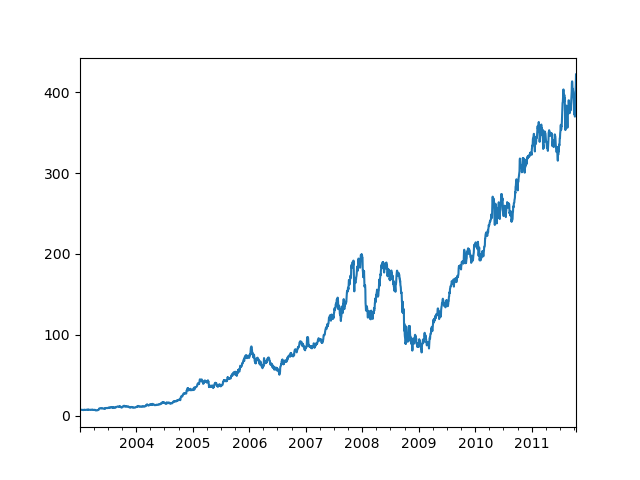

In [244]:
close_px["AAPL"].plot()

In [245]:
close_px["AAPL"].rolling(250).mean().plot()

<Axes: >

<Figure size 640x480 with 0 Axes>

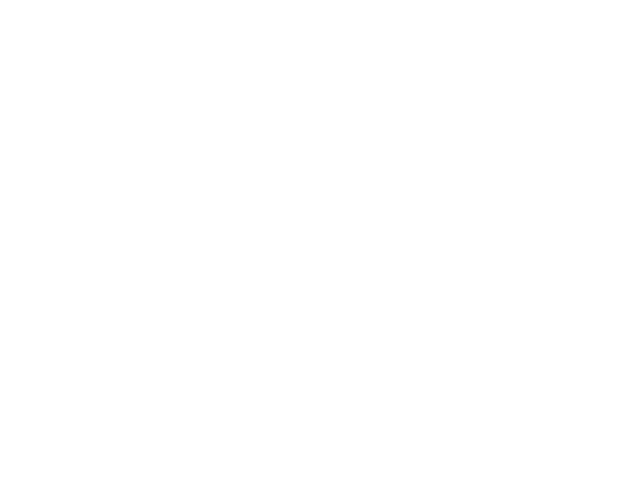

In [246]:
plt.figure()

In [247]:
std250 = close_px["AAPL"].pct_change().rolling(250, min_periods=10).std()

In [248]:
std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.013818
Freq: B, Name: AAPL, dtype: float64

In [249]:
std250.plot()

<Axes: >

In [250]:
expanding_mean = std250.expanding().mean()

In [251]:
plt.style.use('grayscale')

<Axes: >

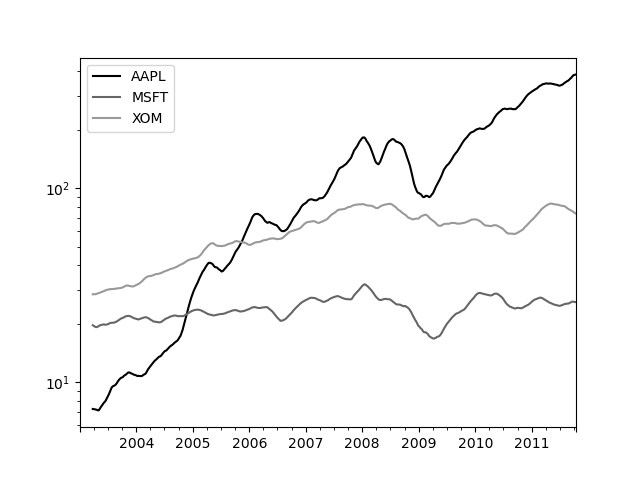

In [252]:
close_px.rolling(60).mean().plot(logy=True)

In [253]:
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


In [254]:
plt.close("all")

# 11.7.1 Exponential weighting function

In [255]:
aapl_px = close_px["AAPL"]["2006":"2007"]

In [256]:
ma30 = aapl_px.rolling(30, min_periods=20).mean()

In [257]:
ewma30 = aapl_px.ewm(span=30).mean()

<Axes: >

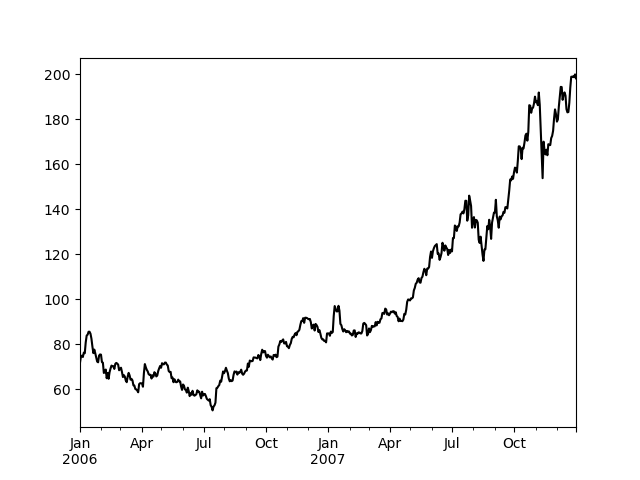

In [258]:
aapl_px.plot(style="k-", label="Price")

In [259]:
ma30.plot(style="k-", label="Simple Moving Avg")

<Axes: >

In [260]:
ewma30.plot(style="k-", label="EW MA")

<Axes: >

In [261]:
plt.legend()

In [262]:
plt.close("all")

# 11.7.2 Binary moving window function

In [263]:
spx_px = close_px_all["SPX"]

In [264]:
spx_rets = spx_px.pct_change()

In [265]:
returns = close_px.pct_change()

In [266]:
corr = returns["AAPL"].rolling(125, min_periods=100).corr(spx_rets)

<Axes: >

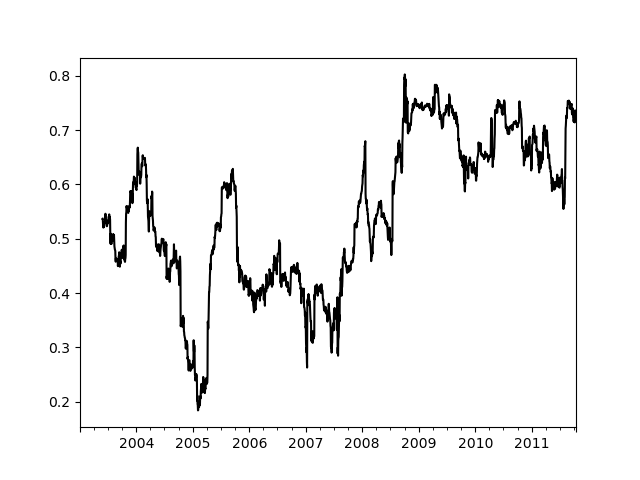

In [267]:
corr.plot()

In [268]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)

<Axes: >

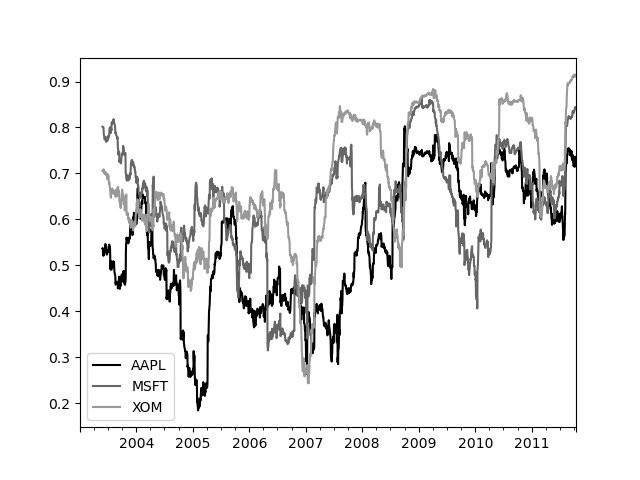

In [269]:
corr.plot()

In [270]:
plt.close("all")

# 11.7.3 User defined moving window function

In [271]:
from scipy.stats import percentileofscore

In [272]:
def score_at_2percent(x):
    return percentileofscore(x, 0.02)

In [273]:
result = returns["AAPL"].rolling(250).apply(score_at_2percent)

<Axes: >

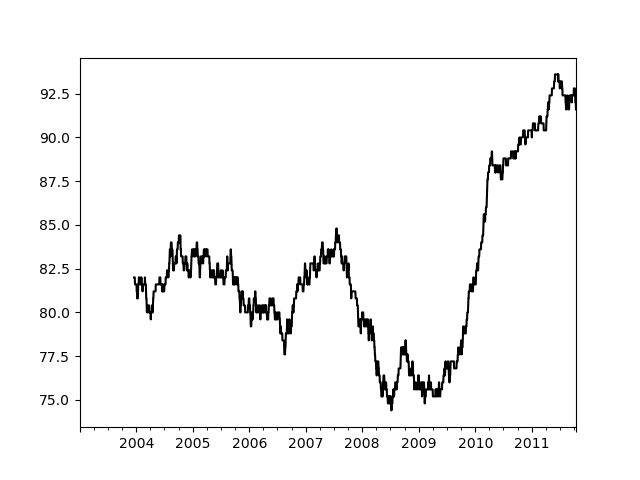

In [274]:
result.plot()